## Score: 30

## Comment: 

<font color=Red>
Q1.[10] Correct
<br><br>
Q2.[10+10] Correct
<br><br>
</font>

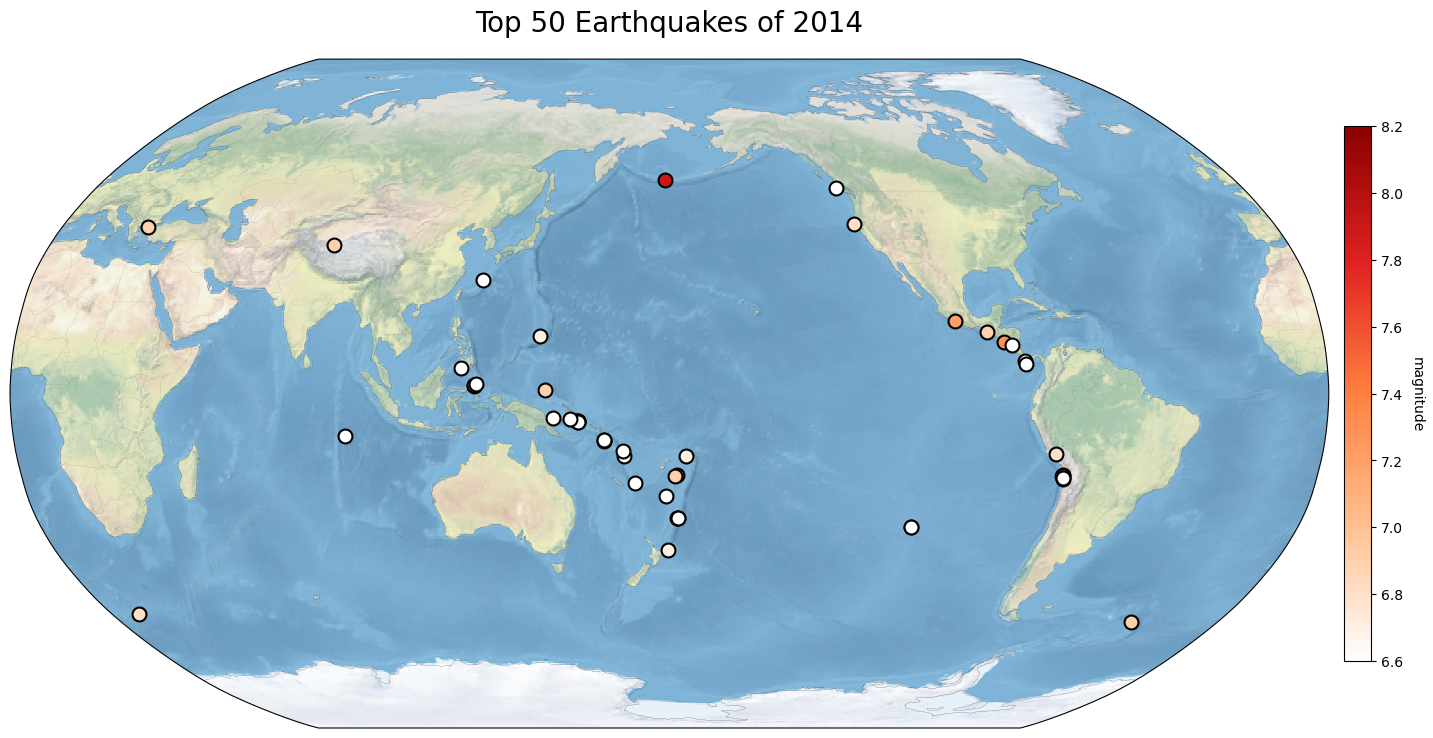

In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.colors import LinearSegmentedColormap
import numpy as np
import xarray as xr  

# 1. 读取+修正地震数据
file_path = "usgs_earthquakes.csv"
df = pd.read_csv(file_path)
df["mag"] = pd.to_numeric(df["mag"], errors="coerce")  
df["time"] = pd.to_datetime(df["time"], errors="coerce")
df["year"] = df["time"].dt.year

# 筛选2014年震级Top50
df_2014_top50 = df[
    (df["year"] == 2014) & (df["mag"].notna())
].sort_values(by="mag", ascending=False).head(50)

# 2. 配置地图
plt.figure(figsize=(16, 8))
ax = plt.axes(projection=ccrs.Robinson(central_longitude=180))
ax.set_global()
ax.stock_img()  # 内置地形图：海洋深蓝（深度渐变）、陆地绿/棕（海拔渐变）
ax.add_feature(cfeature.COASTLINE, linewidth=0.15, edgecolor="#333333")
ax.add_feature(cfeature.BORDERS, linewidth=0.1, linestyle="--", edgecolor="#555555")

# 南极白色区域（覆盖南纬60°以南）
antarctica_mask = ax.projection.transform_points(
    ccrs.PlateCarree(),
    np.array([-180, 180, 180, -180]),
    np.array([-90, -90, -60, -60])
)
ax.fill(
    antarctica_mask[:, 0], antarctica_mask[:, 1],
    facecolor="white", edgecolor="none", zorder=2  # 提高层级覆盖地形
)

ax.set_title("Top 50 Earthquakes of 2014", fontsize=20, pad=20)

# 3. 绘制地震点
cmap = LinearSegmentedColormap.from_list(
    "mag_cmap", ["white", "#FFC090", "#FF8040", "#E02020", "#8B0000"], N=256
)
norm = plt.Normalize(vmin=6.6, vmax=8.2)

for idx, row in df_2014_top50.iterrows():
    mag = row["mag"]
    lat = row["latitude"]
    lon = row["longitude"]
    
    size = 100
    point_color = cmap(norm(mag))
    
    ax.scatter(
        lon, lat, 
        s=size, color=point_color, edgecolors="black", linewidths=1.5,
        transform=ccrs.PlateCarree(), zorder=10  # 地震点层级最高
    )

# 4. 色条
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(
    sm, ax=ax, shrink=0.7, orientation="vertical", pad=0.01,
    ticks=[8.2, 8.0, 7.8, 7.6, 7.4, 7.2, 7.0, 6.8, 6.6]
)
cbar.set_label("magnitude", rotation=270, labelpad=15, fontsize=10)

plt.tight_layout()
plt.show()

D:\anaconda\Lib\site-packages\cartopy\mpl\feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


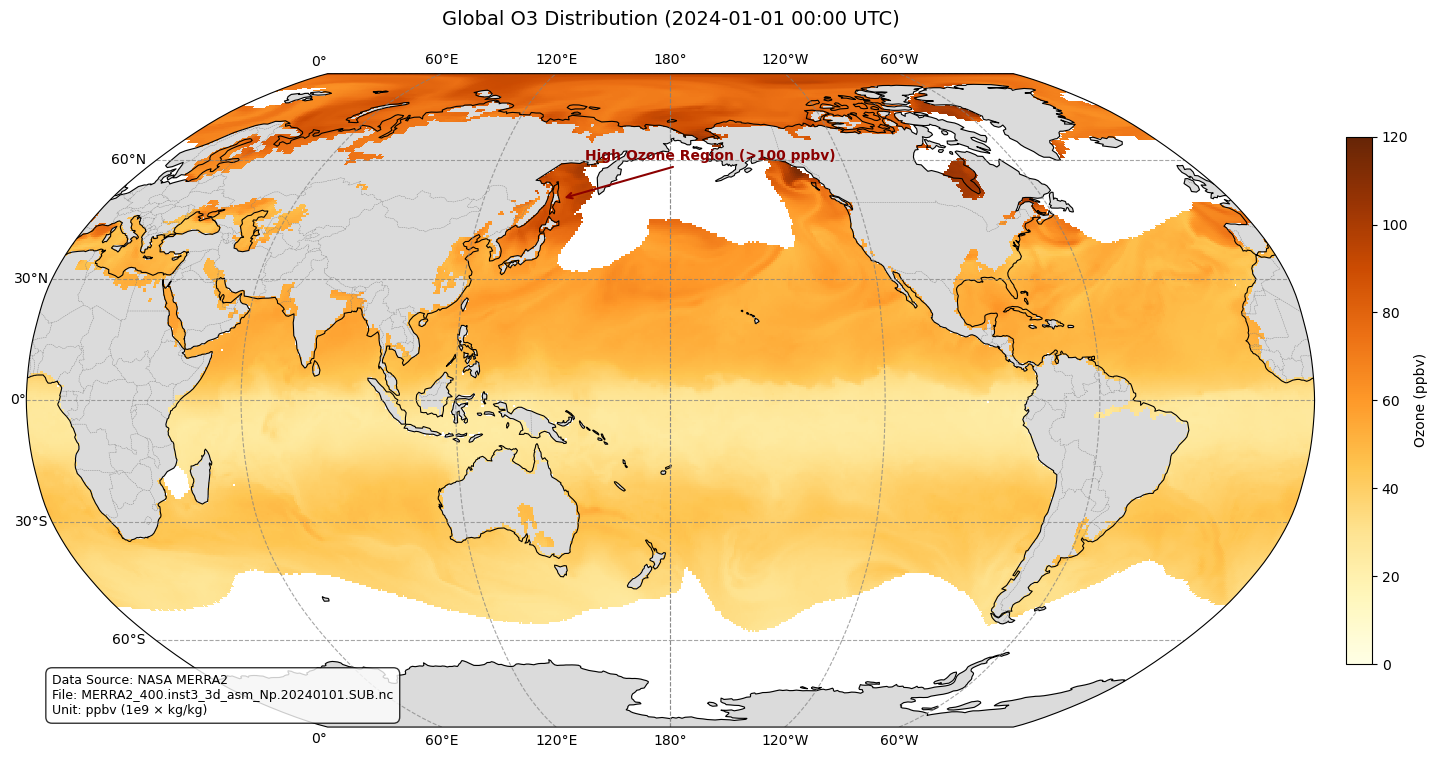

In [8]:
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.colors import LinearSegmentedColormap

# 1.读取并预处理数据
file_path = "MERRA2_400.inst3_3d_asm_Np.20240101.SUB.nc"  # 查找文件路径
ds = xr.open_dataset(file_path)

# 选择2024-01-01 00:00、1000hPa层级的O3数据 → 转换为ppbv（乘以1e9）
o3_data = ds["O3"].sel(
    time="2024-01-01T00:00:00",
    lev=1000.0,
    method="nearest"
) * 1e9  # kg/kg → ppbv

# 处理缺失值+透明化
cmap = plt.cm.YlOrBr  # 匹配配色
cmap.set_bad('none')  # 缺失值设为透明，避免覆盖地图要素
o3_data = o3_data.where(o3_data != (999999986991104.0 * 1e9), np.nan)  # 同步转换缺失值


# 2.1全球地图
fig1 = plt.figure(figsize=(16, 8))
# 投影：Robinson（中心经度180°）
proj = ccrs.Robinson(central_longitude=180)
ax1 = plt.axes(projection=proj)

# 绘制O3数据（色棒范围0-120 ppbv）
im1 = o3_data.plot(
    ax=ax1,
    transform=ccrs.PlateCarree(),
    cmap=cmap,
    vmin=0, vmax=120,
    cbar_kwargs={
        "label": "Ozone (ppbv)",  # 修正色棒标签
        "shrink": 0.7,
        "pad": 0.02
    },
    add_colorbar=True
)

# 地图要素
ax1.add_feature(cfeature.LAND, color='lightgray', alpha=0.8)  # 陆地色
ax1.add_feature(cfeature.OCEAN, color='white', alpha=0.2)    # 海洋色
ax1.add_feature(cfeature.COASTLINE, linewidth=0.8)           # 海岸线
ax1.add_feature(cfeature.BORDERS, linewidth=0.3, color='gray', linestyle="--")  # 国界线

# 标题
ax1.set_title(
    "Global O3 Distribution (2024-01-01 00:00 UTC)",
    fontsize=14, pad=20
)

# 网格线（带经纬度标签）
ax1.gridlines(
    crs=ccrs.PlateCarree(),
    draw_labels=True,
    linewidth=0.8, linestyle="--", color="gray", alpha=0.7,
    xlocs=np.arange(-180, 181, 60),
    ylocs=np.arange(-90, 91, 30)
)

# 注释（标注高值区）
ax1.annotate(
    "High Ozone Region (>100 ppbv)",
    xy=(145, 50), xycoords=ccrs.PlateCarree()._as_mpl_transform(ax1),
    xytext=(150, 60), textcoords=ccrs.PlateCarree()._as_mpl_transform(ax1),
    arrowprops=dict(arrowstyle="->", color="darkred", lw=1.5),
    fontsize=10, color="darkred", weight="bold"
)

# 文本框（数据说明）
ax1.text(
    0.02, 0.02,
    "Data Source: NASA MERRA2\nFile: MERRA2_400.inst3_3d_asm_Np.20240101.SUB.nc\nUnit: ppbv (1e9 × kg/kg)",
    transform=ax1.transAxes,
    bbox=dict(boxstyle="round,pad=0.5", facecolor="white", alpha=0.8),
    fontsize=9
)

plt.tight_layout()
plt.savefig("Task2_1_Global_O3_Map_ppbv.png", dpi=300, bbox_inches="tight")
plt.show()

D:\anaconda\Lib\site-packages\cartopy\mpl\feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


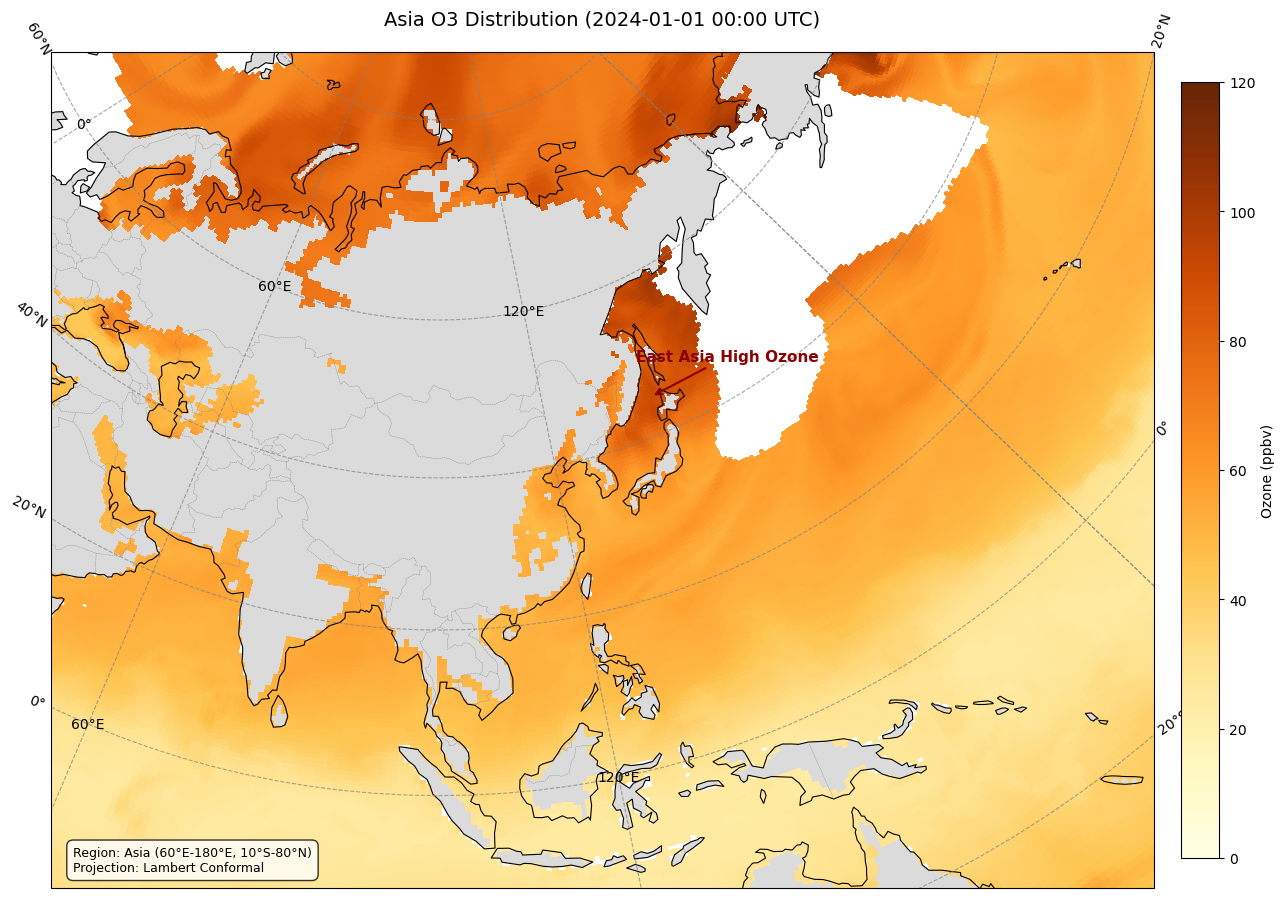

In [10]:
fig2 = plt.figure(figsize=(14, 10))
# 投影：Lambert Conformal
proj_region = ccrs.LambertConformal(
    central_longitude=100,  # 亚洲中心
    central_latitude=40,
    standard_parallels=(25, 45)
)
ax2 = plt.axes(projection=proj_region)
ax2.set_extent([60, 180, -10, 80], crs=ccrs.PlateCarree())  # 亚洲范围

# 绘制O3数据
im2 = o3_data.plot(
    ax=ax2,
    transform=ccrs.PlateCarree(),
    cmap=cmap,
    vmin=0, vmax=120,
    cbar_kwargs={
        "label": "Ozone (ppbv)",
        "shrink": 0.8,
        "pad": 0.02
    },
    add_colorbar=True
)

# 地图要素
ax2.add_feature(cfeature.LAND, color='lightgray', alpha=0.8)
ax2.add_feature(cfeature.OCEAN, color='white', alpha=0.2)
ax2.add_feature(cfeature.COASTLINE, linewidth=0.8)
ax2.add_feature(cfeature.BORDERS, linewidth=0.3, color='gray', linestyle="--")
ax2.add_feature(cfeature.NaturalEarthFeature(
    category='cultural', name='admin_1_states_provinces_lines',
    scale='110m', edgecolor='gray', linewidth=0.3
))

# 标题
ax2.set_title(
    "Asia O3 Distribution (2024-01-01 00:00 UTC)",
    fontsize=14, pad=20
)

# 网格线
ax2.gridlines(
    crs=ccrs.PlateCarree(),
    draw_labels=True,
    linewidth=0.8, linestyle="--", color="gray", alpha=0.7
)

# 注释
ax2.annotate(
    "East Asia High Ozone",
    xy=(140, 45), xycoords=ccrs.PlateCarree()._as_mpl_transform(ax2),
    xytext=(140, 50), textcoords=ccrs.PlateCarree()._as_mpl_transform(ax2),
    arrowprops=dict(arrowstyle="->", color="darkred", lw=1.5),
    fontsize=11, color="darkred", weight="bold"
)

# 文本框
ax2.text(
    0.02, 0.02,
    "Region: Asia (60°E-180°E, 10°S-80°N)\nProjection: Lambert Conformal",
    transform=ax2.transAxes,
    bbox=dict(boxstyle="round,pad=0.5", facecolor="white", alpha=0.8),
    fontsize=9
)

plt.tight_layout()
plt.savefig("Task2_2_Asia_O3_Map_ppbv.png", dpi=300, bbox_inches="tight")
plt.show()